# Notebook 11 — Mixture Fraction: 2-D Reacting Planar Jet

This notebook extends the 1-D counterflow flame to a **2-D reacting planar jet**:
a central fuel jet surrounded by co-flowing air.  The velocity field is prescribed
(no Navier-Stokes solve needed), keeping the focus on the mixture-fraction transport
and flamelet chemistry reconstruction.

## Physical setup

Domain: $x \in [0, L_x]$ (streamwise), $y \in [0, L_y]$ (cross-stream).

A planar fuel jet ($Z=1$) occupies the central strip $|y - L_y/2| < r_{\text{jet}}$
at the inlet ($x=0$).  The surrounding co-flow is air ($Z=0$).  The velocity field
is a prescribed top-hat profile with smooth transition:

$$u(y) = U_{\text{co}} + (U_{\text{jet}} - U_{\text{co}}) \cdot
  \frac{1}{2}\left[1 - \tanh\!\left(\frac{|y - L_y/2| - r_{\text{jet}}}{\delta}\right)\right]$$

The mixture fraction evolves as:

$$\frac{\partial Z}{\partial t} + u(y)\frac{\partial Z}{\partial x} = D\nabla^2 Z$$

Flame location, temperature, and species are reconstructed from $Z$ using the
Burke-Schumann flamelet table.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator

from upde import MixtureFraction, PDESystem
from upde.chemistry import FlameletTable

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

## 1. Domain and velocity field

Grid: 64×32  (2,048 cells)
u range: [0.10, 1.00] m/s


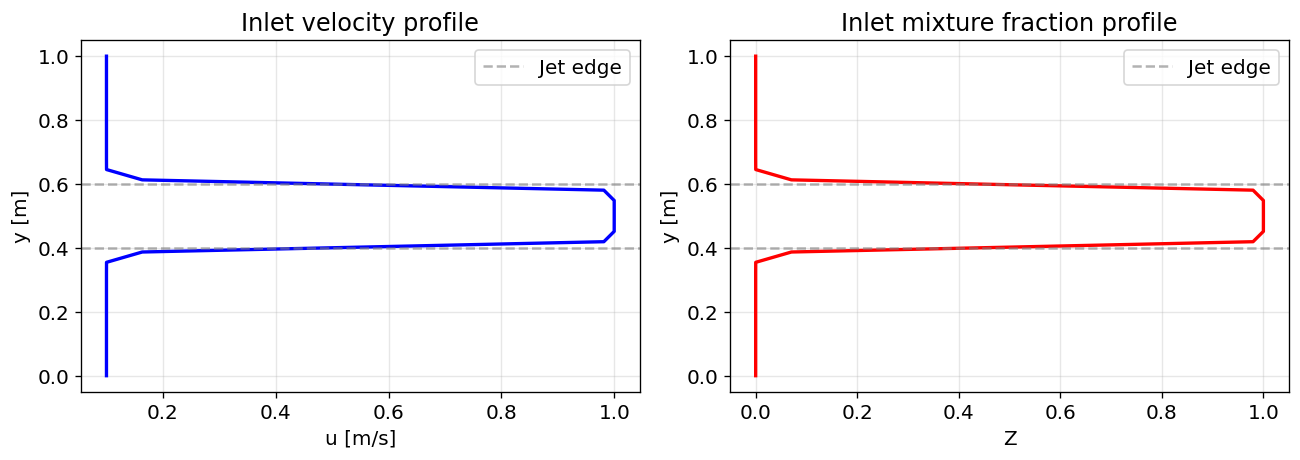

In [5]:
# --- Domain ---
Lx, Ly = 2.0, 1.0          # [m] domain size (streamwise × cross-stream)
Nx, Ny = 64, 32           # grid points

x = np.linspace(0.0, Lx, Nx)
y = np.linspace(0.0, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')   # shape (Nx, Ny)

# --- Jet parameters ---
y_c    = Ly / 2.0    # jet centreline
r_jet  = 0.1         # jet half-width [m]
U_jet  = 1.0         # jet velocity [m/s]
U_co   = 0.1         # co-flow velocity [m/s]
delta  = 0.01        # shear-layer thickness [m]
D      = 5e-4        # scalar diffusivity [m²/s]

# Smooth top-hat velocity profile u(y)
u_field = U_co + (U_jet - U_co) * 0.5 * (
    1.0 - np.tanh((np.abs(Y - y_c) - r_jet) / delta)
)

# --- Inlet Z profile: fuel jet in centre, air in co-flow ---
# Same tanh profile as velocity (assume equal momentum thickness)
Z_inlet_1d = 0.5 * (1.0 - np.tanh((np.abs(y - y_c) - r_jet) / delta))
Z_inlet_2d = np.broadcast_to(Z_inlet_1d, (Nx, Ny)).copy()

print(f'Grid: {Nx}×{Ny}  ({Nx*Ny:,} cells)')
print(f'u range: [{u_field.min():.2f}, {u_field.max():.2f}] m/s')

# Plot velocity and inlet Z
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(u_field[0, :], y, 'b-', lw=2)
axes[0].axhline(y_c + r_jet, color='gray', ls='--', alpha=0.6, label='Jet edge')
axes[0].axhline(y_c - r_jet, color='gray', ls='--', alpha=0.6)
axes[0].set(xlabel='u [m/s]', ylabel='y [m]', title='Inlet velocity profile')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(Z_inlet_1d, y, 'r-', lw=2)
axes[1].axhline(y_c + r_jet, color='gray', ls='--', alpha=0.6, label='Jet edge')
axes[1].axhline(y_c - r_jet, color='gray', ls='--', alpha=0.6)
axes[1].set(xlabel='Z', ylabel='y [m]', title='Inlet mixture fraction profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig11_inlet_profiles.png', bbox_inches='tight')
plt.show()

## 2. Build the flamelet table

In [6]:
Z_st = 0.055
table = FlameletTable.burke_schumann(
    Z_st=Z_st, T_fuel=300.0, T_ox=300.0, T_ad=2230.0
)
print(table)
print(f'Stoichiometric Z: {table.Z_st:.4f}')

FlameletTable(n=500, Z=[0.000,1.000], T=[300,2228]K, species=['CH4', 'O2', 'CO2', 'H2O', 'N2'])
Stoichiometric Z: 0.0561


## 3. Set up and solve the 2-D mixture-fraction equation

Boundary conditions:
- **Left** ($x=0$): Dirichlet, $Z = Z_{\text{inlet}}(y)$ — fuel jet + co-flow air inlet
- **Right** ($x=L_x$): Neumann, $\partial Z/\partial x = 0$ — outflow
- **Bottom** ($y=0$), **Top** ($y=L_y$): Neumann, $\partial Z/\partial y = 0$ — symmetry / free-stream

Initial condition: $Z = 0$ everywhere (domain initially filled with air).

In [7]:
eq = MixtureFraction('Z', x=x, y=y,
                     velocity_x=u_field,   # prescribed: shape (Nx, Ny)
                     velocity_y=0.0,
                     diffusivity=D)

# Left inlet: fuel jet in centre, air elsewhere
# Two set_bc calls: one for jet strip, one for co-flow remainder
jet_mask_left  = np.zeros((Nx, Ny), dtype=bool)
coflow_mask_left = np.zeros((Nx, Ny), dtype=bool)
jet_mask_left[0, :]     = np.abs(y - y_c) < r_jet
coflow_mask_left[0, :]  = np.abs(y - y_c) >= r_jet

eq.set_bc(mask=jet_mask_left,    kind='dirichlet', value=1.0)   # fuel
eq.set_bc(mask=coflow_mask_left, kind='dirichlet', value=0.0)   # air

# Outflow (right): zero-gradient
eq.set_bc(side='right',  kind='neumann', value=0.0)
# Top and bottom: zero-gradient (symmetry)
eq.set_bc(side='bottom', kind='neumann', value=0.0)
eq.set_bc(side='top',    kind='neumann', value=0.0)

# IC: air everywhere
eq.set_ic(0.0)

# Solve to steady state
# Advection time scale: L_x / U_jet = 2.0 s
# Diffusion time scale: L_y^2 / D = 1^2 / 5e-4 = 2000 s
# Run to t >> advection time to reach quasi-steady state
t_end = 20.0
t_store = np.linspace(0, t_end, 50)

print('Solving 2-D mixture-fraction transport...')
sol = PDESystem([eq]).solve(
    t_span=(0, t_end),
    t_eval=t_store,
    method='BDF',
    rtol=1e-4, atol=1e-6,
)
print(f'Success: {sol.success}  |  {sol.message}')
print(f'Z range at t={sol.t[-1]:.1f}s: [{sol.Z[:,:,-1].min():.4f}, {sol.Z[:,:,-1].max():.4f}]')

Solving 2-D mixture-fraction transport...
Success: True  |  The solver successfully reached the end of the integration interval.
Z range at t=20.0s: [-0.0000, 1.0000]


## 4. Reconstruct temperature and species fields

In [8]:
# Final time snapshot
Z_final   = sol.Z[:, :, -1]          # shape (Nx, Ny)
T_final   = table.T(Z_final)
Y_CH4     = table.Y('CH4', Z_final)
Y_O2      = table.Y('O2',  Z_final)
Y_CO2     = table.Y('CO2', Z_final)
Y_H2O     = table.Y('H2O', Z_final)

# Stoichiometric surface: Z = Z_st contour (flame surface)
print(f'Peak temperature in domain:  {T_final.max():.1f} K')
print(f'Adiabatic flame temperature: {table.T(np.array([Z_st]))[0]:.1f} K')

Peak temperature in domain:  2224.2 K
Adiabatic flame temperature: 2211.6 K


In [9]:
def plot_2d_field(field, title, cmap='hot', vmin=None, vmax=None, 
                  contour_Z=None, contour_label=True):
    """Helper: 2-D colour plot with optional stoichiometric contour."""
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.pcolormesh(X, Y, field, cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='auto')
    plt.colorbar(im, ax=ax, pad=0.01)
    if contour_Z is not None:
        cs = ax.contour(X, Y, contour_Z, levels=[Z_st],
                        colors='white', linewidths=1.5, linestyles='--')
        if contour_label:
            ax.clabel(cs, fmt=f'$Z_{{st}}={Z_st}$', fontsize=9, inline=True)
    ax.set(xlabel='x [m]', ylabel='y [m]', title=title)
    ax.set_aspect('equal')
    plt.tight_layout()
    return fig, ax

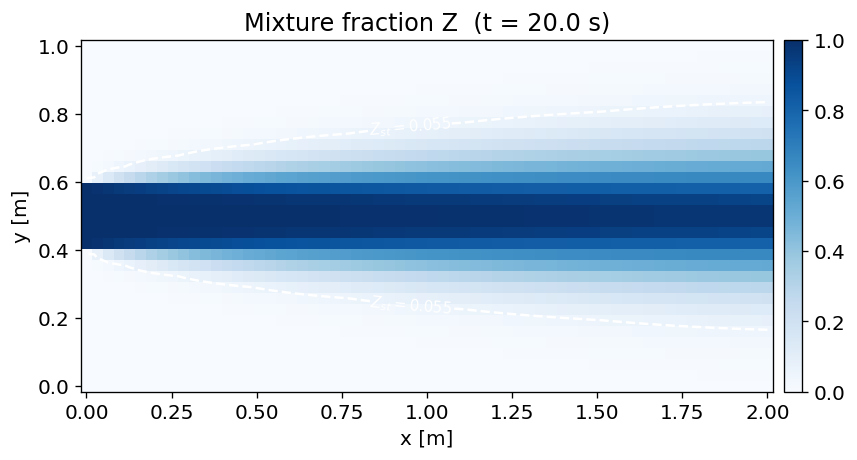

In [10]:
# --- Mixture fraction ---
fig, ax = plot_2d_field(Z_final, 
    title=f'Mixture fraction Z  (t = {sol.t[-1]:.1f} s)',
    cmap='Blues', vmin=0, vmax=1,
    contour_Z=Z_final)
plt.savefig('fig11_Z_final.png', bbox_inches='tight')
plt.show()

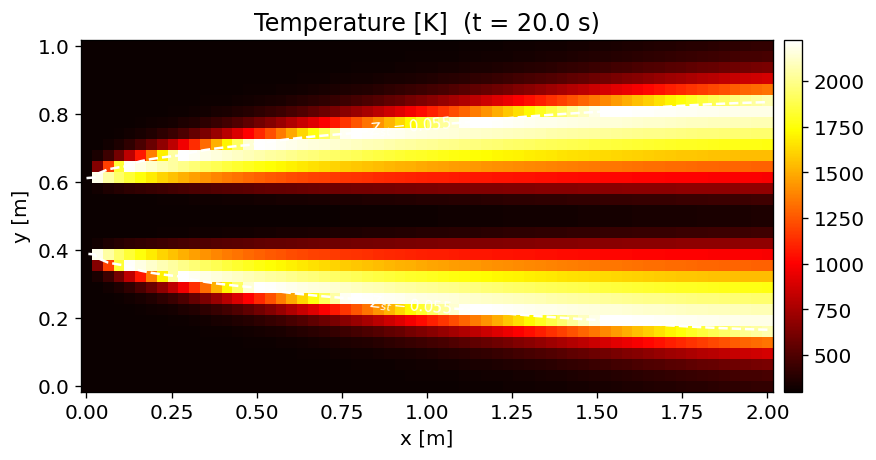

In [11]:
# --- Temperature (the "flame" is the bright region) ---
fig, ax = plot_2d_field(T_final,
    title=f'Temperature [K]  (t = {sol.t[-1]:.1f} s)',
    cmap='hot', vmin=300, vmax=T_final.max(),
    contour_Z=Z_final)
plt.savefig('fig11_T_final.png', bbox_inches='tight')
plt.show()

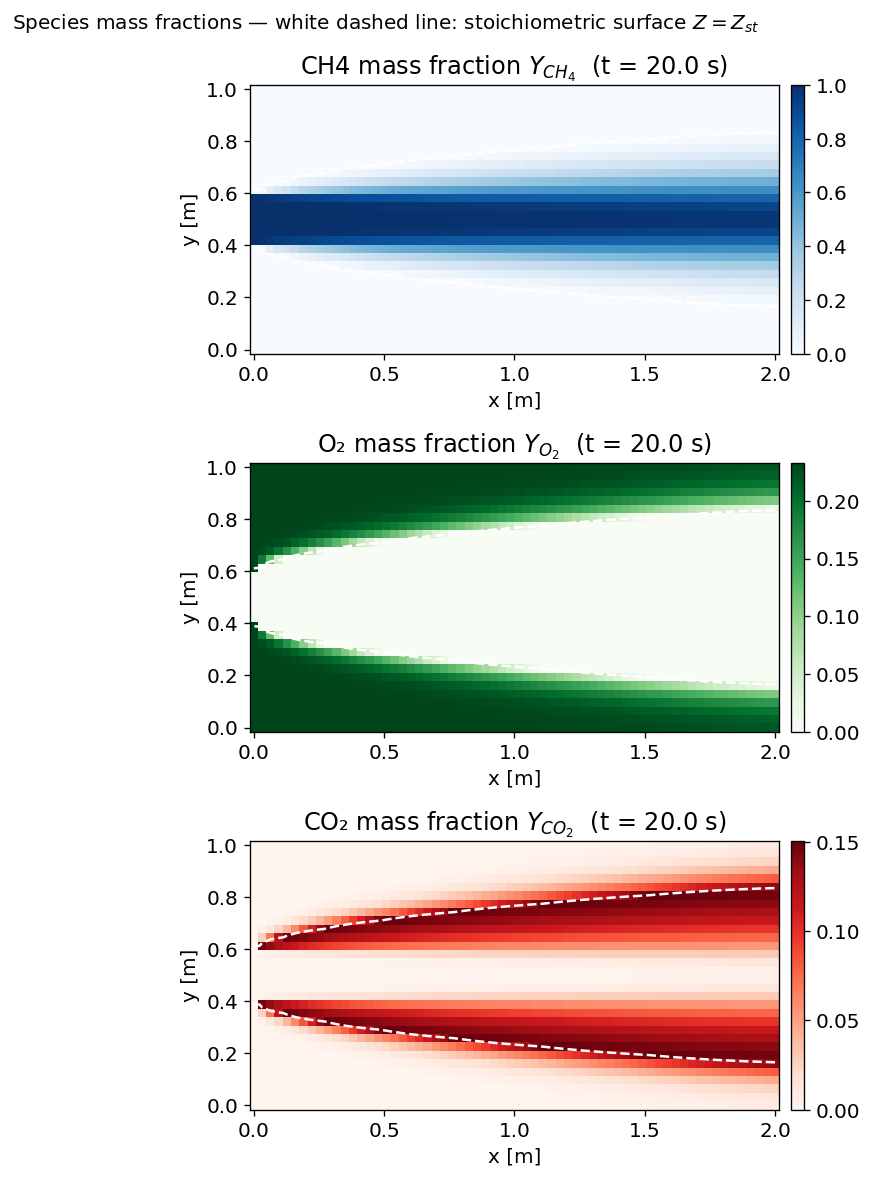

In [12]:
# --- Species: CH4 (fuel), O2 (oxidiser), CO2 (product) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
fields_to_plot = [
    (Y_CH4, 'CH4 mass fraction $Y_{{CH_4}}$', 'Blues'),
    (Y_O2,  'O₂ mass fraction $Y_{{O_2}}$',   'Greens'),
    (Y_CO2, 'CO₂ mass fraction $Y_{{CO_2}}$', 'Reds'),
]
for ax, (field, title, cmap) in zip(axes, fields_to_plot):
    im = ax.pcolormesh(X, Y, field, cmap=cmap, shading='auto')
    plt.colorbar(im, ax=ax, pad=0.01)
    ax.contour(X, Y, Z_final, levels=[Z_st],
               colors='white', linewidths=1.5, linestyles='--')
    ax.set(xlabel='x [m]', ylabel='y [m]',
           title=f'{title}  (t = {sol.t[-1]:.1f} s)')
    ax.set_aspect('equal')

plt.suptitle('Species mass fractions — white dashed line: stoichiometric surface $Z = Z_{st}$',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig11_species_2d.png', bbox_inches='tight')
plt.show()

## 5. Temporal evolution

Watch the jet flame develop from the initial air-filled domain to a quasi-steady
state where the fuel jet burns along its length.

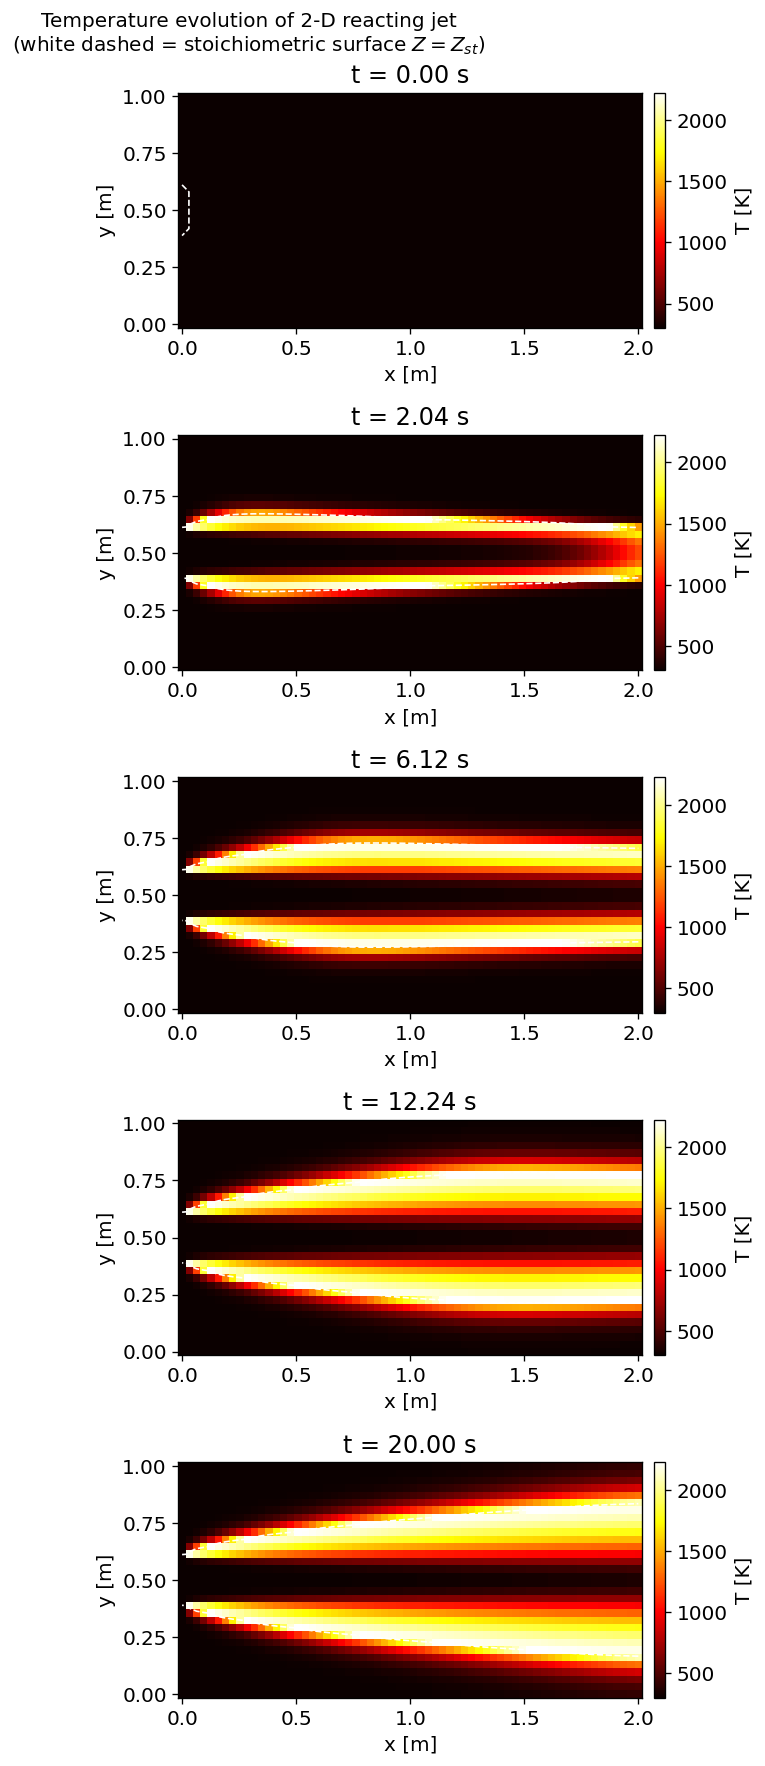

In [13]:
t_snap_indices = [0, 5, 15, 30, 49]   # time snapshot indices

fig, axes = plt.subplots(len(t_snap_indices), 1,
                         figsize=(10, 3*len(t_snap_indices)))

for ax, idx in zip(axes, t_snap_indices):
    Z_snap = sol.Z[:, :, idx]
    T_snap = table.T(Z_snap)
    im = ax.pcolormesh(X, Y, T_snap, cmap='hot',
                       vmin=300, vmax=T_final.max(), shading='auto')
    ax.contour(X, Y, Z_snap, levels=[Z_st],
               colors='white', linewidths=1.0, linestyles='--')
    plt.colorbar(im, ax=ax, pad=0.01, label='T [K]')
    ax.set(xlabel='x [m]', ylabel='y [m]',
           title=f't = {sol.t[idx]:.2f} s')
    ax.set_aspect('equal')

plt.suptitle('Temperature evolution of 2-D reacting jet\n'
             '(white dashed = stoichiometric surface $Z = Z_{st}$)',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig11_T_evolution.png', bbox_inches='tight')
plt.show()

## 6. Centreline and cross-sectional profiles

Quantitative analysis: $Z$, $T$, and species along the jet centreline
and at a downstream cross-section.

In [ ]:
j_centre = Ny // 2   # centreline index
i_cross  = 3 * Nx // 4  # cross-section at x = 3Lx/4

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Centreline Z and T ---
ax = axes[0, 0]
ax.plot(x, Z_final[:, j_centre], 'b-', lw=2, label='Z')
ax.set(xlabel='x [m]', ylabel='Z', title='Centreline mixture fraction')
ax.axhline(Z_st, color='red', ls='--', label=f'$Z_{{st}} = {Z_st}$')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(x, T_final[:, j_centre], 'r-', lw=2)
ax.set(xlabel='x [m]', ylabel='T [K]', title='Centreline temperature')
ax.grid(True, alpha=0.3)

# --- Cross-section profiles ---
ax = axes[1, 0]
ax.plot(y, Z_final[i_cross, :], 'b-', lw=2, label='Z')
ax.axvline(y_c + r_jet, color='gray', ls=':', alpha=0.7, label='Jet edge')
ax.axvline(y_c - r_jet, color='gray', ls=':', alpha=0.7)
ax.axhline(Z_st, color='red', ls='--', label=f'$Z_{{st}}$')
ax.set(xlabel='y [m]', ylabel='Z',
       title=f'Cross-section Z at x = {x[i_cross]:.2f} m')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(y, T_final[i_cross, :],        'r-',  lw=2, label='T [K]')
ax.axvline(y_c + r_jet, color='gray', ls=':', alpha=0.7)
ax.axvline(y_c - r_jet, color='gray', ls=':', alpha=0.7)
ax.set(xlabel='y [m]', ylabel='',
       title=f'Cross-section T at x = {x[i_cross]:.2f} m')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

ax_r = ax.twinx()
ax_r.plot(y, Y_CH4[i_cross, :], 'b--',  lw=1.5, label='$Y_{CH_4}$')
ax_r.plot(y, Y_O2[i_cross,  :], 'g--',  lw=1.5, label='$Y_{O_2}$')
ax_r.plot(y, Y_CO2[i_cross, :], 'r--',  lw=1.5, label='$Y_{CO_2}$')
ax_r.set_ylabel('Mass fraction')
ax_r.legend(fontsize=8, loc='upper left')

plt.suptitle('Centreline and cross-section profiles (steady state)', fontsize=13)
plt.tight_layout()
plt.savefig('fig11_profiles.png', bbox_inches='tight')
plt.show()

## 7. Effect of diffusivity (flame width)

The mixture fraction diffusivity $D$ controls how rapidly fuel and oxidiser mix.
Larger $D$ → wider flame, lower peak temperature gradients.

In [ ]:
D_values = [1e-4, 5e-4, 2e-3]
labels   = ['D = 1×10⁻⁴', 'D = 5×10⁻⁴', 'D = 2×10⁻³']
cmaps    = ['Blues', 'Oranges', 'Greens']

fig, axes = plt.subplots(len(D_values), 1, figsize=(10, 3*len(D_values)))

for ax, D_val, label, cmap in zip(axes, D_values, labels, cmaps):
    eq_d = MixtureFraction('Z', x=x, y=y,
                           velocity_x=u_field, velocity_y=0.0,
                           diffusivity=D_val)
    eq_d.set_bc(mask=jet_mask_left,    kind='dirichlet', value=1.0)
    eq_d.set_bc(mask=coflow_mask_left, kind='dirichlet', value=0.0)
    eq_d.set_bc(side='right',  kind='neumann', value=0.0)
    eq_d.set_bc(side='bottom', kind='neumann', value=0.0)
    eq_d.set_bc(side='top',    kind='neumann', value=0.0)
    eq_d.set_ic(0.0)

    sol_d = PDESystem([eq_d]).solve(
        t_span=(0, 20.0), method='BDF', rtol=1e-4, atol=1e-6
    )
    Z_d = sol_d.Z[:, :, -1]
    T_d = table.T(Z_d)

    im = ax.pcolormesh(X, Y, T_d, cmap='hot', vmin=300, vmax=T_final.max(),
                       shading='auto')
    ax.contour(X, Y, Z_d, levels=[Z_st],
               colors='white', linewidths=1.5, linestyles='--')
    plt.colorbar(im, ax=ax, pad=0.01, label='T [K]')
    ax.set(xlabel='x [m]', ylabel='y [m]',
           title=f'Temperature — {label} m²/s')
    ax.set_aspect('equal')

plt.suptitle('Effect of diffusivity on flame width\n'
             '(white dashed = $Z = Z_{st}$ flame surface)', fontsize=12)
plt.tight_layout()
plt.savefig('fig11_diffusivity_comparison.png', bbox_inches='tight')
plt.show()

## 8. Density field (ideal gas)

The `FlameletTable.rho()` method computes density from the ideal-gas law
using the mean molecular weight of the mixture.

In [ ]:
rho_final = table.rho(Z_final, P=101325.0)

fig, ax = plot_2d_field(rho_final,
    title=f'Density [kg/m³]  (t = {sol.t[-1]:.1f} s)',
    cmap='viridis_r',
    contour_Z=Z_final)

print(f'Density range: [{rho_final.min():.3f}, {rho_final.max():.3f}] kg/m³')
print(f'Cold air density (300 K, 1 atm): {101325*0.02897/(8314*300):.3f} kg/m³')
print(f'Hot products density (2230 K, 1 atm): ~{101325*0.026/(8314*2230):.3f} kg/m³')

plt.savefig('fig11_rho_final.png', bbox_inches='tight')
plt.show()

## Summary

This notebook demonstrated:

1. **2-D mixture-fraction transport** with prescribed jet velocity — solved by uPDE's
   `MixtureFraction` factory as a pure convection-diffusion problem
2. **Flamelet table lookups** — temperature, species, and density reconstructed from
   $Z(x,y,t)$ via `numpy.interp` with zero additional stiffness
3. **Stoichiometric surface** — the flame lives on the $Z = Z_{st}$ contour, clearly
   visible as the white dashed line in all temperature plots
4. **Parametric study** — effect of diffusivity on flame width demonstrated with
   three separate solves

### Extension: fully coupled reacting flow

To couple the mixture-fraction transport with the Navier-Stokes solver, combine
`MixtureFraction` with `NavierStokes2D` in a single `PDESystem`, using the velocity
fields `u` and `v` from the NS equations as `velocity_x='u'` and `velocity_y='v'`:

```python
ns = NavierStokes2D('u', 'v', 'p', x=x, y=y, nu=1e-4)
zz = MixtureFraction('Z', x=x, y=y, velocity_x='u', velocity_y='v', diffusivity=D)
sol = PDESystem([ns.u_eq, ns.v_eq, ns.p_eq, zz]).solve(...)
```

See notebook 09 (jet + passive scalar) for the NS coupling pattern.